In [28]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import seaborn as sns

from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

from playsound import playsound
from scipy.interpolate import interp1d

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
from scipy import stats

sys.path.append(os.path.abspath(".."))
from function import ART_bias
from function import ART_downscale as ART_down

import warnings
warnings.filterwarnings('ignore')

In [29]:
correction, nameout, label = 'Linear-Regression-origin', 'LTO', 'Linear Regression Origin'

In [30]:
# product, time_reso = 'IMERG', '1dy'
product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'CHIRPS', '1dy'

# product, time_reso = 'ERA5', '3h'

# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'GSMaP', '3h'

In [31]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy')

dir_cal = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC','CAL_VAL', 'Calibration')
dir_val = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC','CAL_VAL', 'Validation')

## Load MEVd Data

In [32]:
data_dir = os.path.join(dir_base, 'Satellite','5_DOWN', f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(data_dir)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
years = DATA.year.values

## Load METDATA

In [33]:
# seeds_list = [7, 19, 31, 53, 89, 127, 211, 307, 401, 509, 613, 727, 839, 947, 1051]

primos_50 = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71,
            73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151,
            157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229]

np.random.seed(123)
aleatorios_50 = np.random.choice(range(1000, 10000), size=50, replace=False).tolist()

seeds_list = primos_50 + aleatorios_50

In [34]:
RE_SAT_MAT = np.zeros([879,len(seeds_list)])
RE_DOWN_MAT = np.zeros([879,len(seeds_list)])

Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

pos = 0
for seed in seeds_list:

    METADATA_VAL = pd.read_csv(os.path.join(dir_val, f'METADATA_VAL_seed{seed}.csv'))

    lon_list, lat_list = [], []
    RE_DOWN_list, RE_SAT_list = [], []

    for nn in range(len(METADATA_VAL)):

        name = METADATA_VAL['File'].values[nn]
        ISO = METADATA_VAL['ISO'].values[nn]
        lat_obs = METADATA_VAL['Lat'].values[nn]
        lon_obs = METADATA_VAL['Lon'].values[nn]

        dir_station = os.path.join(dir_base,'Rain_Gauges_QC','Weibull','1dy',ISO,name)
        DF_OBS = pd.read_csv(dir_station)
        DF_OBS = DF_OBS.drop(columns='NaN')

        PREC_DOWN = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')

        DF_SAT = pd.DataFrame({
                            'Year':PREC_DOWN.year.values, 
                            'Ns':PREC_DOWN.NYs.values, 'Cs':PREC_DOWN.CYs.values, 'Ws':PREC_DOWN.WYs.values,
                            'Nd':PREC_DOWN.NYd.values, 'Cd':PREC_DOWN.CYd.values, 'Wd':PREC_DOWN.WYd.values})

        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

        merged_df_clean = merged_df.dropna(subset=['N'])
        
        if merged_df_clean.Ns.values.sum() == 0 or np.isnan(merged_df_clean.Ns.values.sum()) == True:
            RE_DOWN_list.append(np.nan)
            RE_SAT_list.append(np.nan)

        else:
            x0 = 9.0*np.nanmean(merged_df_clean.C.values)
            quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
            QQ_OBS = np.where(flag, quant, np.nan)

            x0 = 9.0*np.nanmean(merged_df_clean.Cs.values)
            quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Ns.values, merged_df_clean.Cs.values, merged_df_clean.Ws.values, thresh=1)
            QQ_SAT = np.where(flag, quant, np.nan)

            x0 = 9.0*np.nanmean(merged_df_clean.Cd.values)
            quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Nd.values, merged_df_clean.Cd.values, merged_df_clean.Wd.values, thresh=1)
            QQ_DOWN = np.where(flag, quant, np.nan)

            RE_SAT = (QQ_SAT - QQ_OBS) / QQ_OBS
            RE_DOWN = (QQ_DOWN - QQ_OBS) / QQ_OBS
            
            RE_DOWN_list.append(RE_DOWN[3])
            RE_SAT_list.append(RE_SAT[3])
            lon_list.append(lon_obs)
            lat_list.append(lat_obs)

    RE_SAT_MAT[:,pos] = np.array(RE_SAT_list)
    RE_DOWN_MAT[:,pos] = np.array(RE_DOWN_list)

    pos = pos + 1

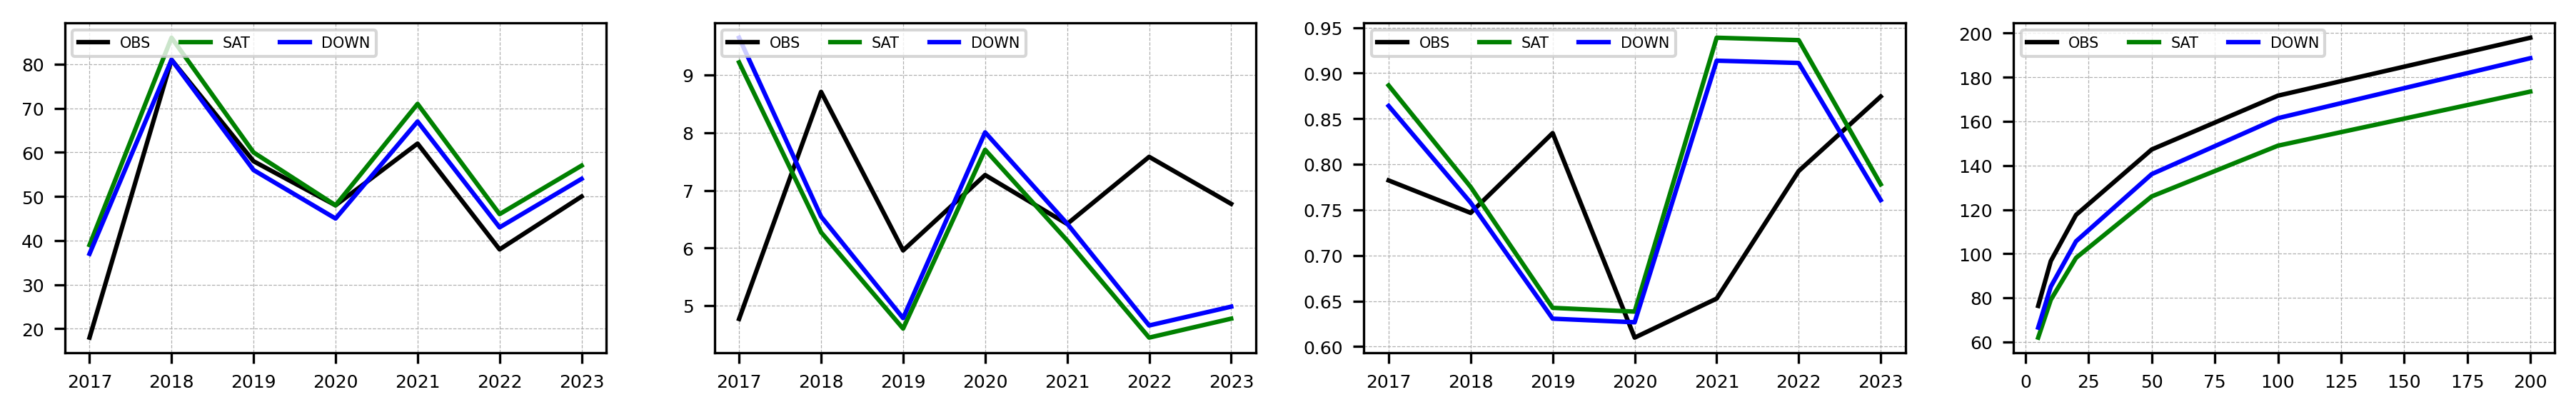

In [35]:
fig = plt.figure(figsize=(15,2),dpi=300)
gs = gridspec.GridSpec(1,4)

# =============================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.plot(merged_df_clean.Year, merged_df_clean.N, c='k', label='OBS')
ax1.plot(merged_df_clean.Year, merged_df_clean.Ns, c='g', label='SAT')
ax1.plot(merged_df_clean.Year, merged_df_clean.Nd, c='b', label='DOWN')
plt.legend(fontsize=5,loc=2, ncol=3)
ax1.tick_params(axis='both', which='major', labelsize=6)
plt.grid(linewidth=0.3, linestyle='--')

# =============================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.plot(merged_df_clean.Year, merged_df_clean.C, c='k', label='OBS')
ax1.plot(merged_df_clean.Year, merged_df_clean.Cs, c='g', label='SAT')
ax1.plot(merged_df_clean.Year, merged_df_clean.Cd, c='b', label='DOWN')
plt.legend(fontsize=5,loc=2, ncol=3)
ax1.tick_params(axis='both', which='major', labelsize=6)
plt.grid(linewidth=0.3, linestyle='--')

# =============================================================================
ax1 = plt.subplot(gs[0, 2])
ax1.plot(merged_df_clean.Year, merged_df_clean.W, c='k', label='OBS')
ax1.plot(merged_df_clean.Year, merged_df_clean.Ws, c='g', label='SAT')
ax1.plot(merged_df_clean.Year, merged_df_clean.Wd, c='b', label='DOWN')
plt.legend(fontsize=5,loc=2, ncol=3)
ax1.tick_params(axis='both', which='major', labelsize=6)
plt.grid(linewidth=0.3, linestyle='--')

# =============================================================================
ax1 = plt.subplot(gs[0, 3])
ax1.plot(Tr, QQ_OBS, c='k', label='OBS')
ax1.plot(Tr, QQ_SAT, c='g', label='SAT')
ax1.plot(Tr, QQ_DOWN, c='b', label='DOWN')
plt.legend(fontsize=5,loc=2, ncol=3)
ax1.tick_params(axis='both', which='major', labelsize=6)
plt.grid(linewidth=0.3, linestyle='--')

## Create nc with SAT corrected data

In [36]:
RE_SAT_CORR_MAT = np.zeros([879,len(seeds_list)])

Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

pos = 0
for seed in seeds_list:

    METADATA_CAL = pd.read_csv(os.path.join(dir_cal, f'METADATA_CAL_seed{seed}.csv'))
    METADATA_VAL = pd.read_csv(os.path.join(dir_val, f'METADATA_VAL_seed{seed}.csv'))

    RE_SAT_CORR_list = []

    for nn in range(len(METADATA_CAL)):

        name = METADATA_CAL['File'].values[nn]
        ISO = METADATA_CAL['ISO'].values[nn]
        lat_obs = METADATA_CAL['Lat'].values[nn]
        lon_obs = METADATA_CAL['Lon'].values[nn]

        dir_station = os.path.join(dir_base,'Rain_Gauges_QC','Weibull','1dy',ISO,name)
        DF_OBS = pd.read_csv(dir_station)
        DF_OBS = DF_OBS.drop(columns='NaN')

        # print(f'Number of years: {len(DF_OBS)}')

        PREC_DOWN = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')

        DF_SAT = pd.DataFrame({
                            'Year':PREC_DOWN.year.values, 
                            'Ns':PREC_DOWN.NYs.values, 'Cs':PREC_DOWN.CYs.values, 'Ws':PREC_DOWN.WYs.values,
                            'Nd':PREC_DOWN.NYd.values, 'Cd':PREC_DOWN.CYd.values, 'Wd':PREC_DOWN.WYd.values})

        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

        merged_df_clean = merged_df.dropna(subset=['N'])

    NYs_corrected = ART_bias.linear_bc_through_origin(merged_df_clean.N.values,merged_df_clean.Ns.values,DATA.NYs.values)
    CYs_corrected = ART_bias.linear_bc_through_origin(merged_df_clean.C.values,merged_df_clean.Cs.values,DATA.CYs.values)
    WYs_corrected = ART_bias.linear_bc_through_origin(merged_df_clean.W.values,merged_df_clean.Ws.values,DATA.WYs.values)

    SAT_corrected = xr.Dataset(
                            data_vars={
                                "NYs": (("year","lat","lon"), NYs_corrected),
                                "CYs": (("year","lat","lon"), CYs_corrected),
                                "WYs": (("year","lat","lon"), WYs_corrected),
                                },
                            coords={
                                'year': years, 
                                'lat': lats, 
                                'lon': lons
                                },
                            attrs=dict(description=f"{product} Weibull parameters and MEV corrected applying ISIMIP_QM method using 80% of stations in Italy",))

    for nn in range(len(METADATA_VAL)):

        name = METADATA_VAL['File'].values[nn]
        ISO = METADATA_VAL['ISO'].values[nn]
        lat_obs = METADATA_VAL['Lat'].values[nn]
        lon_obs = METADATA_VAL['Lon'].values[nn]

        dir_station = os.path.join(dir_base,'Rain_Gauges_QC','Weibull','1dy',ISO,name)
        DF_OBS = pd.read_csv(dir_station)
        DF_OBS = DF_OBS.drop(columns='NaN')

        PREC_SAT = SAT_corrected.sel(lat=lat_obs, lon=lon_obs, method='nearest')
        
        DF_SAT = pd.DataFrame({
                            'Year':PREC_SAT.year.values, 
                            'Ns':PREC_SAT.NYs.values, 'Cs':PREC_SAT.CYs.values, 'Ws':PREC_SAT.WYs.values})

        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

        merged_df_clean = merged_df.dropna(subset=['N'])
        
        if merged_df_clean.Ns.values.sum() == 0 or np.isnan(merged_df_clean.Ns.values.sum()) == True:
            RE_SAT_CORR_list.append(np.nan)

        else:
            x0 = 9.0*np.nanmean(merged_df_clean.C.values)
            quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
            QQ_OBS = np.where(flag, quant, np.nan)

            x0 = 9.0*np.nanmean(merged_df_clean.Cs.values)
            quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Ns.values, merged_df_clean.Cs.values, merged_df_clean.Ws.values, thresh=1)
            QQ_SAT = np.where(flag, quant, np.nan)

            RE_SAT_CORR = (QQ_SAT - QQ_OBS) / QQ_OBS

            RE_SAT_CORR_list.append(RE_SAT_CORR[3])

    RE_SAT_CORR_MAT[:,pos] = np.array(RE_SAT_CORR_list)

    pos = pos + 1

In [37]:
umbral = 1.3

mask_sat = np.any(RE_SAT_MAT > umbral, axis=1)
mask_down = np.any(RE_DOWN_MAT > umbral, axis=1)
mask_corr = np.any(RE_SAT_CORR_MAT > umbral, axis=1)

mask_combinada = mask_sat | mask_down | mask_corr

RE_SAT_MAT[mask_combinada, :] = np.nan
RE_DOWN_MAT[mask_combinada, :] = np.nan
RE_SAT_CORR_MAT[mask_combinada, :] = np.nan

## KDE median distribution

/home/arturo/Pictures/test/RE_CMORPH.png


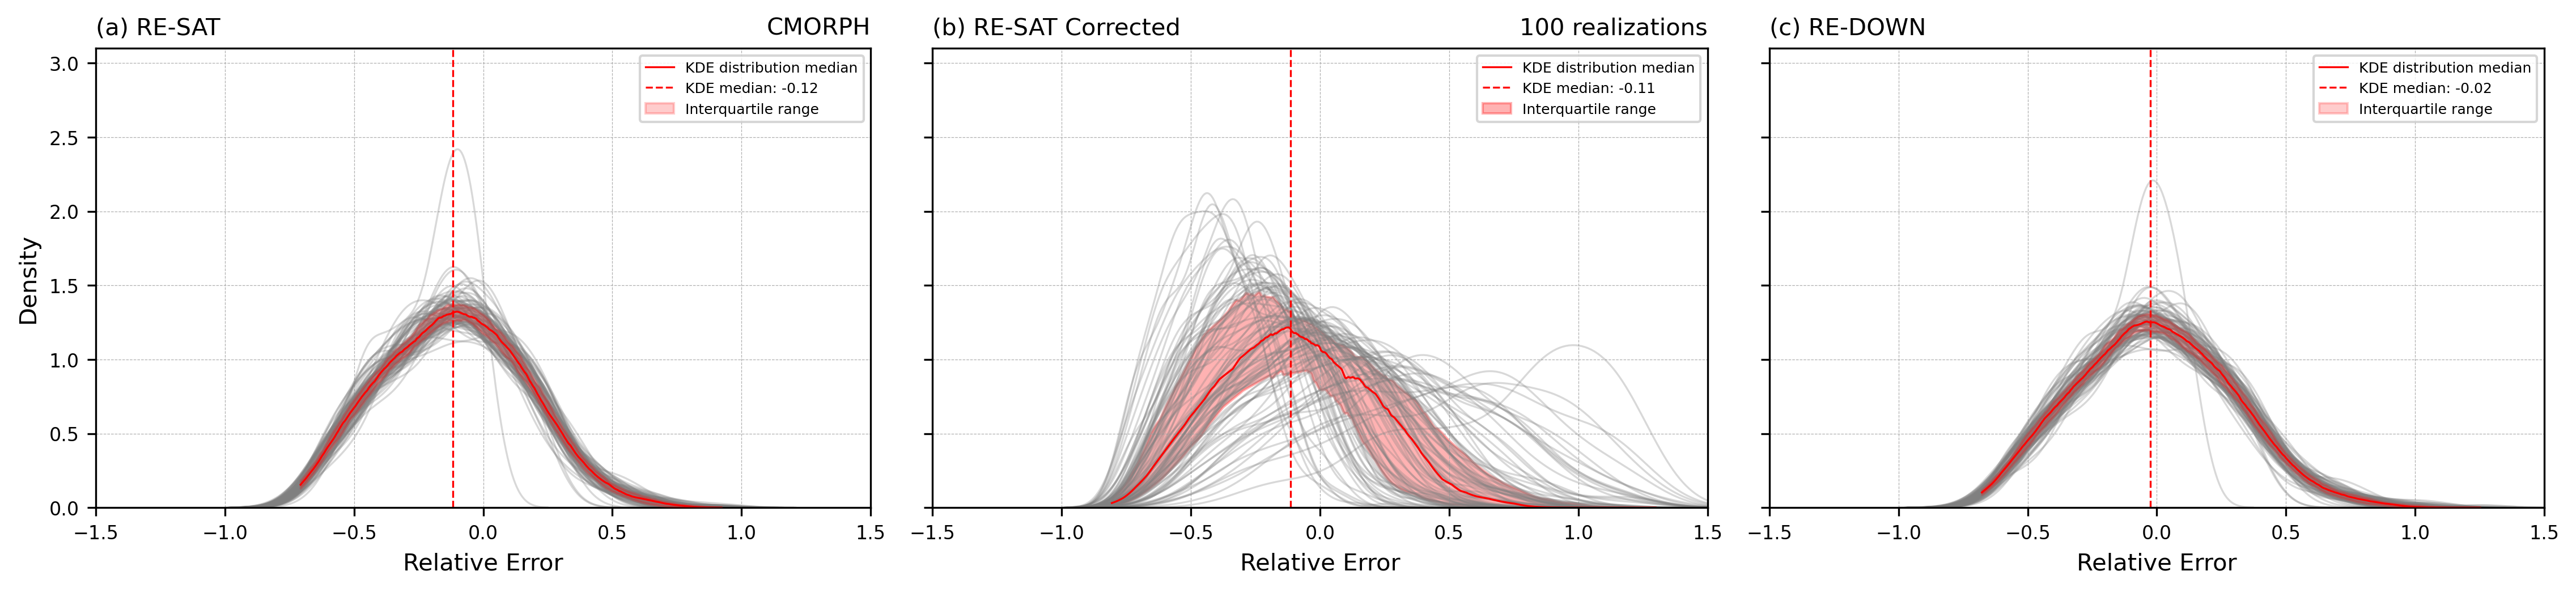

In [38]:
fig = plt.figure(figsize=(16,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0])
# Plotear todas las realizaciones individuales (como ya lo haces)
for nn in range(RE_SAT_MAT.shape[1]):
    sns.kdeplot(RE_SAT_MAT[:, nn], color='gray', alpha=0.3, linewidth=0.8, ax=ax1)

# Calcular y plotear la "distribución mediana" usando bootstrap/percentiles
# Método: en cada punto x de la KDE, calcular la mediana de las densidades
# Crear un grid común para evaluar todas las KDEs
x_grid = np.linspace(np.nanmin(RE_SAT_MAT), np.nanmax(RE_SAT_MAT), 500)

# Evaluar KDE para cada realización en el grid común
kde_values = np.zeros((len(x_grid), RE_SAT_MAT.shape[1]))

for nn in range(RE_SAT_MAT.shape[1]):
    # Usar scipy para KDE en lugar de seaborn para tener control
    data = RE_SAT_MAT[:, nn][~np.isnan(RE_SAT_MAT[:, nn])]
    if len(data) > 1:
        kde = gaussian_kde(data)
        kde_values[:, nn] = kde(x_grid)

# Calcular mediana y percentiles de las densidades en cada punto x
median_kde = np.nanmedian(kde_values, axis=1)
p25_kde = np.nanpercentile(kde_values, 25, axis=1)
p75_kde = np.nanpercentile(kde_values, 75, axis=1)

# Plotear la KDE mediana
ax1.plot(x_grid, median_kde, color='red', linewidth=0.8, label='KDE distribution median')
ax1.axvline(x=np.nanmedian(RE_SAT_MAT,axis=[0,1]), color='red', linestyle='--', linewidth=0.8, label=f'KDE median: {np.round(np.nanmedian(RE_SAT_MAT,axis=[0,1]),2)}')

# Sombreado de la dispersión
ax1.fill_between(x_grid, p25_kde, p75_kde, alpha=0.2, color='red',label='Interquartile range',zorder=40)

ax1.set_xlabel('Relative Error')
ax1.set_ylabel('Density')
ax1.set_title('(a) RE-SAT',loc='left',fontsize=10)
ax1.set_title(f'{product}',loc='right',fontsize=10)
ax1.legend(fontsize=6,loc=1)
ax1.set_xlim(-1.5,1.5)
ax1.set_ylim(0,3.1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 1])
# Plotear todas las realizaciones individuales (como ya lo haces)
for nn in range(RE_SAT_CORR_MAT.shape[1]):
    sns.kdeplot(RE_SAT_CORR_MAT[:, nn], color='gray', alpha=0.3, linewidth=0.8, ax=ax1)

# Calcular y plotear la "distribución mediana" usando bootstrap/percentiles
# Método: en cada punto x de la KDE, calcular la mediana de las densidades
# Crear un grid común para evaluar todas las KDEs
x_grid = np.linspace(np.nanmin(RE_SAT_CORR_MAT), np.nanmax(RE_SAT_CORR_MAT), 500)

# Evaluar KDE para cada realización en el grid común
kde_values = np.zeros((len(x_grid), RE_SAT_CORR_MAT.shape[1]))

for nn in range(RE_SAT_CORR_MAT.shape[1]):
    # Usar scipy para KDE en lugar de seaborn para tener control
    data = RE_SAT_CORR_MAT[:, nn][~np.isnan(RE_SAT_CORR_MAT[:, nn])]
    if len(data) > 1:
        kde = gaussian_kde(data)
        kde_values[:, nn] = kde(x_grid)

# Calcular mediana y percentiles de las densidades en cada punto x
median_kde = np.nanmedian(kde_values, axis=1)
p25_kde = np.nanpercentile(kde_values, 25, axis=1)
p75_kde = np.nanpercentile(kde_values, 75, axis=1)

# Plotear la KDE mediana
ax1.plot(x_grid, median_kde, color='red', linewidth=0.8, label='KDE distribution median')
ax1.axvline(x=np.nanmedian(RE_SAT_CORR_MAT,axis=[0,1]), color='red', linestyle='--', linewidth=0.8, label=f'KDE median: {np.round(np.nanmedian(RE_SAT_CORR_MAT,axis=[0,1]),2)}')

# Sombreado de la dispersión
ax1.fill_between(x_grid, p25_kde, p75_kde, alpha=0.3, color='red',label='Interquartile range')

ax1.set_xlabel('Relative Error')
ax1.set_yticklabels([])
ax1.set_ylabel('')
ax1.set_title('(b) RE-SAT Corrected',loc='left',fontsize=10)
ax1.set_title(f'{len(seeds_list)} realizations',loc='right',fontsize=10)
ax1.legend(fontsize=6,loc=1)
ax1.set_xlim(-1.5,1.5)
ax1.set_ylim(0,3.1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 2])
# Plotear todas las realizaciones individuales (como ya lo haces)
for nn in range(RE_DOWN_MAT.shape[1]):
    sns.kdeplot(RE_DOWN_MAT[:, nn], color='gray', alpha=0.3, linewidth=0.8, ax=ax1)

# Calcular y plotear la "distribución mediana" usando bootstrap/percentiles
# Método: en cada punto x de la KDE, calcular la mediana de las densidades
# Crear un grid común para evaluar todas las KDEs
x_grid = np.linspace(np.nanmin(RE_DOWN_MAT), np.nanmax(RE_DOWN_MAT), 500)

# Evaluar KDE para cada realización en el grid común
kde_values = np.zeros((len(x_grid), RE_DOWN_MAT.shape[1]))

for nn in range(RE_DOWN_MAT.shape[1]):
    # Usar scipy para KDE en lugar de seaborn para tener control
    data = RE_DOWN_MAT[:, nn][~np.isnan(RE_DOWN_MAT[:, nn])]
    if len(data) > 1:
        kde = gaussian_kde(data)
        kde_values[:, nn] = kde(x_grid)

# Calcular mediana y percentiles de las densidades en cada punto x
median_kde = np.nanmedian(kde_values, axis=1)
p25_kde = np.nanpercentile(kde_values, 25, axis=1)
p75_kde = np.nanpercentile(kde_values, 75, axis=1)

# Plotear la KDE mediana
ax1.plot(x_grid, median_kde, color='red', linewidth=0.8, label='KDE distribution median')
ax1.axvline(x=np.nanmedian(RE_DOWN_MAT,axis=[0,1]), color='red', linestyle='--', linewidth=0.8, label=f'KDE median: {np.round(np.nanmedian(RE_DOWN_MAT,axis=[0,1]),2)}')

# Sombreado de la dispersión
ax1.fill_between(x_grid, p25_kde, p75_kde, alpha=0.2, color='red',label='Interquartile range',zorder=40)

ax1.set_xlabel('Relative Error')
ax1.set_yticklabels([])
ax1.set_ylabel('')
ax1.set_title('(c) RE-DOWN',loc='left',fontsize=10)
ax1.legend(fontsize=6,loc=1)
ax1.set_xlim(-1.5,1.5)
ax1.set_ylim(0,3.1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.08, hspace=0.1)

salida = f'/home/arturo/Pictures/test/RE_{product}.png'
print(salida)
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

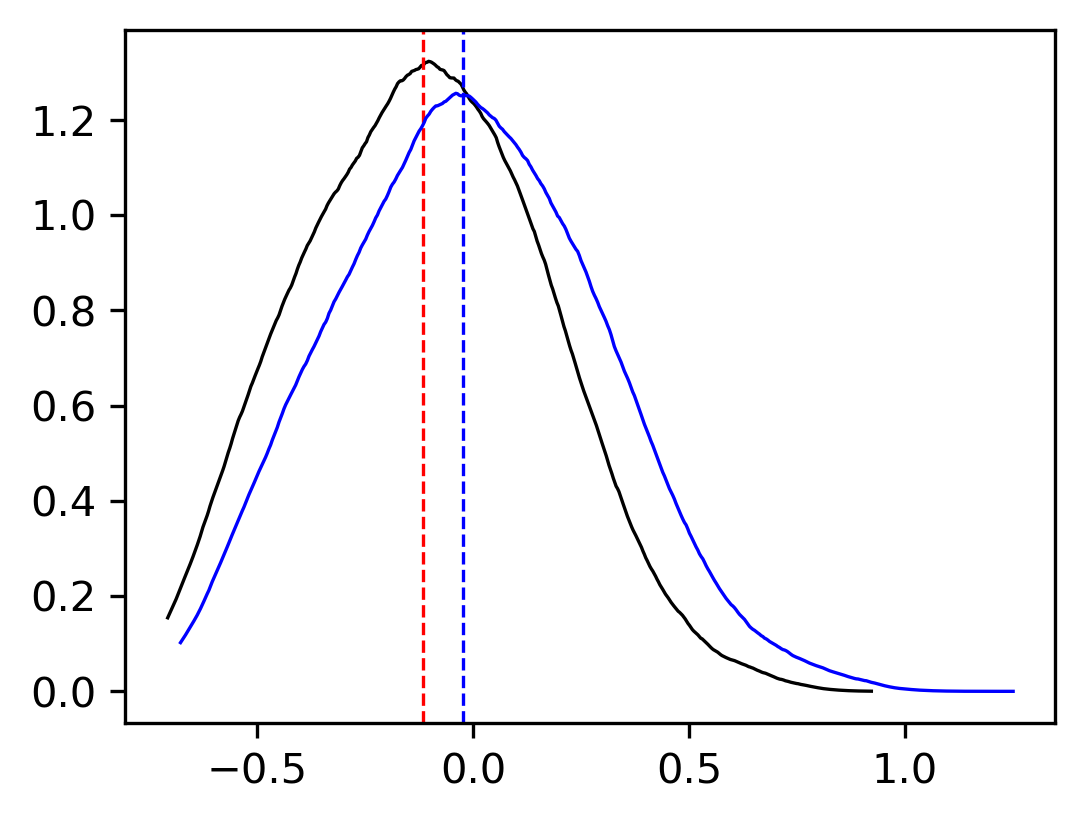

In [41]:
fig = plt.figure(figsize=(4,3),dpi=300)
gs = gridspec.GridSpec(1,1)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0])

x_grid = np.linspace(np.nanmin(RE_SAT_MAT), np.nanmax(RE_SAT_MAT), 500)
# Evaluar KDE para cada realización en el grid común
kde_values = np.zeros((len(x_grid), RE_SAT_MAT.shape[1]))

for nn in range(RE_SAT_MAT.shape[1]):
    # Usar scipy para KDE en lugar de seaborn para tener control
    data = RE_SAT_MAT[:, nn][~np.isnan(RE_SAT_MAT[:, nn])]
    if len(data) > 1:
        kde = gaussian_kde(data)
        kde_values[:, nn] = kde(x_grid)

# Calcular mediana y percentiles de las densidades en cada punto x
median_kde = np.nanmedian(kde_values, axis=1)
ax1.plot(x_grid, median_kde, color='k', linewidth=0.8, label='KDE median')
ax1.axvline(x=np.nanmedian(RE_SAT_MAT,axis=[0,1]), color='red', linestyle='--', linewidth=0.8, label=f'KDE median: {np.round(np.nanmedian(RE_SAT_MAT,axis=[0,1]),2)}')

# ===================================================================================================================================================
x_grid = np.linspace(np.nanmin(RE_DOWN_MAT), np.nanmax(RE_DOWN_MAT), 500)
# Evaluar KDE para cada realización en el grid común
kde_values = np.zeros((len(x_grid), RE_DOWN_MAT.shape[1]))

for nn in range(RE_DOWN_MAT.shape[1]):
    # Usar scipy para KDE en lugar de seaborn para tener control
    data = RE_DOWN_MAT[:, nn][~np.isnan(RE_DOWN_MAT[:, nn])]
    if len(data) > 1:
        kde = gaussian_kde(data)
        kde_values[:, nn] = kde(x_grid)

# Calcular mediana y percentiles de las densidades en cada punto x
median_kde = np.nanmedian(kde_values, axis=1)
ax1.plot(x_grid, median_kde, color='b', linewidth=0.8, label='KDE median')
ax1.axvline(x=np.nanmedian(RE_DOWN_MAT,axis=[0,1]), color='b', linestyle='--', linewidth=0.8, label=f'KDE median: {np.round(np.nanmedian(RE_DOWN_MAT,axis=[0,1]),2)}')